# Explore Autoregressive Methods on TiRex

In [1]:
import sys
sys.path.append('../tirex/src') # Add the path to the tirex module
sys.path.append('../src') # Add the path to source modules

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch

from tirex import ForecastModel, load_model
from tirex.util import plot_forecast

# set default figure size for all plots
plt.rcParams["figure.figsize"] = (12, 6)

# Load data

In [26]:
data_base_url = "https://raw.githubusercontent.com/NX-AI/tirex/refs/heads/main/tests/data/"
data_short = pl.read_csv(f"{data_base_url}/air_passengers.csv").to_numpy().reshape(-1)
data_long = pl.read_csv(f"{data_base_url}/loop_seattle_5T.csv").to_numpy().reshape(-1)

print(Shape_short := data_short.shape)
print(Shape_long := data_long.shape)

(143,)
(2527,)


In [47]:
# energy data
path = "../data/home_electricity/electricity.csv"
data_energy = pl.read_csv(path, try_parse_dates=True, separator=";", decimal_comma=True)
data_energy

Datum,kWh,kW,Status,
datetime[μs],f64,f64,str,str
2024-09-01 00:00:00,0.046,0.184,"""VALID""",null
2024-09-01 00:15:00,0.041,0.164,"""VALID""",null
2024-09-01 00:30:00,0.034,0.136,"""VALID""",null
2024-09-01 00:45:00,0.039,0.156,"""VALID""",null
2024-09-01 01:00:00,0.039,0.156,"""VALID""",null
…,…,…,…,…
2025-08-31 22:45:00,0.097,0.388,"""VALID""",null
2025-08-31 23:00:00,0.165,0.66,"""VALID""",null
2025-08-31 23:15:00,0.195,0.78,"""VALID""",null


# Load Model

In [12]:
model: ForecastModel = load_model("NX-AI/TiRex")

model.ckpt:   0%|          | 0.00/141M [00:00<?, ?B/s]

c:\py_venv\pw_tirex\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\degri\.cache\huggingface\hub\models--NX-AI--TiRex. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [20]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")
model

Total Parameters: 35,291,200


TiRexZero(
  (input_patch_embedding): ResidualBlock(
    (hidden_layer): Linear(in_features=64, out_features=2048, bias=True)
    (output_layer): Linear(in_features=2048, out_features=512, bias=True)
    (residual_layer): Linear(in_features=64, out_features=512, bias=True)
  )
  (blocks): ModuleList(
    (0-11): 12 x sLSTMBlock(
      (norm_slstm): RMSNorm()
      (slstm_layer): sLSTMLayer(
        (fgate): LinearHeadwiseExpand()
        (igate): LinearHeadwiseExpand()
        (zgate): LinearHeadwiseExpand()
        (ogate): LinearHeadwiseExpand()
        (slstm_cell): sLSTMCell()
        (group_norm): MultiHeadLayerNorm()
      )
      (norm_ffn): RMSNorm()
      (ffn): FeedForward(
        (proj_up_gate): Linear(in_features=512, out_features=1408, bias=False)
        (proj_up): Linear(in_features=512, out_features=1408, bias=False)
        (proj_down): Linear(in_features=1408, out_features=512, bias=False)
      )
    )
  )
  (out_norm): RMSNorm()
  (output_patch_embedding): Residual

# Prediction

In [75]:
data = data_energy['kW'].to_numpy()
prediction_length = 24*4*31

data = data_long
prediction_length = 3000

ctx_s, future_s = np.split(data, [-128])
ctx_s.shape, future_s.shape

((2399,), (128,))

In [76]:
quantiles, mean = model.forecast(torch.as_tensor(ctx_s), prediction_length=prediction_length)
print(quantiles.shape)
print(mean.shape)

torch.Size([1, 3000, 9])
torch.Size([1, 3000])


<Axes: >

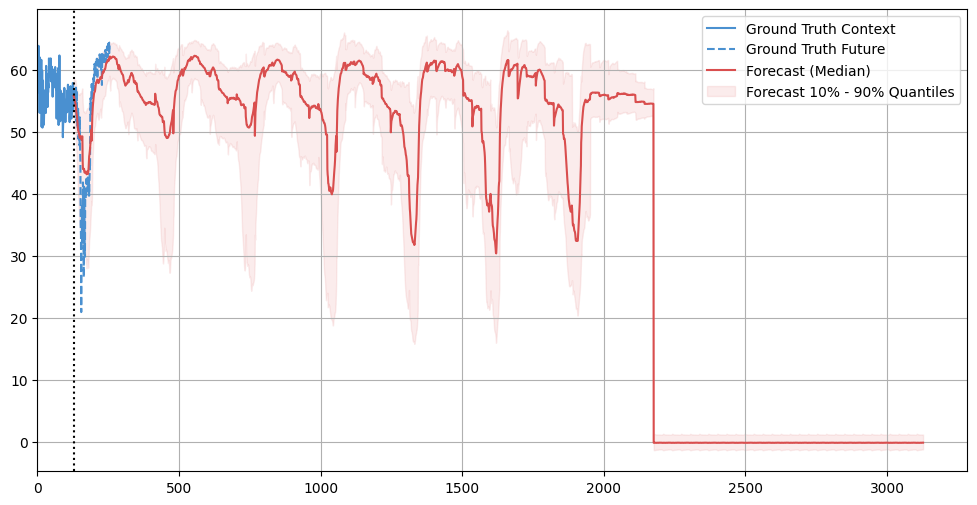

In [77]:
plot_forecast(ctx_s[-128:], quantiles.numpy()[0], future_s)